Using device: cpu


100%|██████████| 9.91M/9.91M [00:07<00:00, 1.39MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 74.6kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 714kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.99MB/s]



Training → No reg
Epoch  1 | Train acc: 93.21% | Test acc: 95.42%
Epoch  2 | Train acc: 96.75% | Test acc: 96.35%
Epoch  3 | Train acc: 97.41% | Test acc: 96.59%
Epoch  4 | Train acc: 97.78% | Test acc: 97.18%
Epoch  5 | Train acc: 98.14% | Test acc: 96.74%
Epoch  6 | Train acc: 98.22% | Test acc: 96.81%
Epoch  7 | Train acc: 98.38% | Test acc: 97.00%
Epoch  8 | Train acc: 98.41% | Test acc: 97.15%
Epoch  9 | Train acc: 98.69% | Test acc: 97.24%
Epoch 10 | Train acc: 98.73% | Test acc: 97.49%
Epoch 11 | Train acc: 98.67% | Test acc: 97.00%
Epoch 12 | Train acc: 98.80% | Test acc: 97.28%
Epoch 13 | Train acc: 98.86% | Test acc: 97.13%
Epoch 14 | Train acc: 98.81% | Test acc: 97.31%
Epoch 15 | Train acc: 99.07% | Test acc: 97.25%
Epoch 16 | Train acc: 99.02% | Test acc: 97.47%
Epoch 17 | Train acc: 99.05% | Test acc: 97.33%
Epoch 18 | Train acc: 99.03% | Test acc: 97.86%
Epoch 19 | Train acc: 99.27% | Test acc: 97.27%
Epoch 20 | Train acc: 99.02% | Test acc: 97.64%

Training → L2 only
E

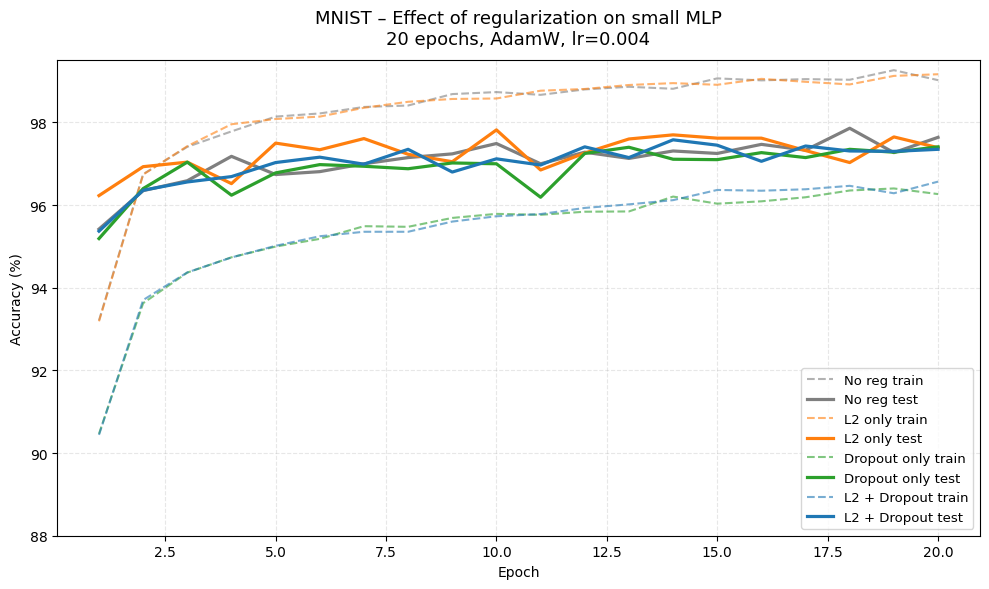

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ────────────────────────────────────────────────
#  Device & Hyperparameters
# ────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

batch_size = 128
epochs = 20
lr = 0.004

# ────────────────────────────────────────────────
#  MNIST Data
# ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=1000,   shuffle=False, num_workers=2)

# ────────────────────────────────────────────────
#  Simple MLP
# ────────────────────────────────────────────────
class MNIST_MLP(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

# ────────────────────────────────────────────────
#  Training function
# ────────────────────────────────────────────────
def train_model(name, dropout_rate=0.0, weight_decay=0.0, color='tab:blue'):
    model = MNIST_MLP(dropout_rate=dropout_rate).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_acc_list = []
    test_acc_list  = []

    print(f"\nTraining → {name}")
    for epoch in range(1, epochs+1):
        model.train()
        correct, total = 0, 0
        for X, y in trainloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            _, pred = out.max(1)
            correct += pred.eq(y).sum().item()
            total += y.size(0)

        train_acc = 100. * correct / total
        train_acc_list.append(train_acc)

        # Test
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X, y in testloader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                _, pred = out.max(1)
                correct += pred.eq(y).sum().item()
                total += y.size(0)

        test_acc = 100. * correct / total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch:2d} | Train acc: {train_acc:5.2f}% | Test acc: {test_acc:5.2f}%")

    # Plot learning curve
    plt.plot(range(1, epochs+1), train_acc_list, '--', color=color, alpha=0.6, label=f"{name} train")
    plt.plot(range(1, epochs+1), test_acc_list,  '-',  color=color, lw=2.3, label=f"{name} test")

    return test_acc_list[-1]

# ────────────────────────────────────────────────
#  Run all four experiments
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

final_test_acc = {}

# 1. No regularization
acc = train_model("No reg", dropout_rate=0.0, weight_decay=0.0, color='tab:gray')
final_test_acc["No reg"] = acc

# 2. L2 only (weight decay)
acc = train_model("L2 only", dropout_rate=0.0, weight_decay=1e-4, color='tab:orange')
final_test_acc["L2 only"] = acc

# 3. Dropout only
acc = train_model("Dropout only", dropout_rate=0.35, weight_decay=0.0, color='tab:green')
final_test_acc["Dropout only"] = acc

# 4. L2 + Dropout (mixed — most common choice)
acc = train_model("L2 + Dropout", dropout_rate=0.35, weight_decay=1e-4, color='tab:blue')
final_test_acc["L2 + Dropout"] = acc

# ────────────────────────────────────────────────
#  Final plot & summary
# ────────────────────────────────────────────────
plt.title("MNIST – Effect of regularization on small MLP\n"
          f"20 epochs, AdamW, lr={lr}", fontsize=13, pad=12)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(88, 99.5)
plt.grid(True, alpha=0.3, ls='--')
plt.legend(loc='lower right', fontsize=9.5)
plt.tight_layout()

print("\n" + "═"*60)
print("Final test accuracy after 20 epochs:")
for k, v in final_test_acc.items():
    print(f"  {k:15} : {v:5.2f}%")
print("═"*60)

plt.show()